<a href="https://colab.research.google.com/github/Renato7373/cp2-parte2/blob/main/modelo_regressao_linear_abcr_pib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Modelo de Regressão Linear — Índice ABCR e PIB

**Aluno:** Conrado Gracie  
**Curso:** Ciência da Computação — 2º semestre

**Objetivo:** investigar se existe relação entre a atividade econômica brasileira, representada pelo índice de volume do PIB, e o fluxo de veículos nas rodovias, representado pelo Índice ABCR.

Neste trabalho serão utilizados 20 anos completos em comum, de 2006 a 2025. O modelo terá como entrada o `PIB_indice` e tentará estimar o `ABCR_indice`.


## 1. Entendimento do problema

A ideia é verificar, de forma simples, se anos com maior atividade econômica também tendem a apresentar maior fluxo de veículos nas rodovias.

- **X (entrada):** `PIB_indice`
- **y (alvo):** `ABCR_indice`
- **Período:** 2006 a 2025
- **Treinamento:** primeiros 16 anos (2006–2021)
- **Teste:** últimos 4 anos (2022–2025)

Importante: correlação e regressão linear podem mostrar associação entre as variáveis, mas não provam que uma variável causa a outra.


## 2. Importação das bibliotecas


In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 3. Fontes dos dados

### PIB — IBGE/SIDRA

Será utilizada a **Tabela 1620 — Série encadeada do índice de volume trimestral (Base: média 1995 = 100)**, selecionando Brasil e **PIB a preços de mercado**, sem ajuste sazonal.

A série é trimestral. Por isso, para cada ano será calculada a média dos quatro trimestres.

### Índice ABCR

O Índice ABCR mede o fluxo de veículos em rodovias concedidas. Para o trabalho será utilizada a série de fluxo total.

A base `dados_abcr_2006_2025.csv` contém os valores anuais usados no notebook. Os valores de 2006–2021 seguem a série histórica publicada em estudos com dados da ABCR/CNT; para 2022–2025 foram atualizados a partir dos crescimentos anuais divulgados pela ABCR/Tendências.


In [2]:
# API do SIDRA utilizada para a Tabela 1620
url_pib = "https://apisidra.ibge.gov.br/values/t/1620/n1/1/v/all/p/all/c11255/90707/d/v583%202"

resposta = requests.get(url_pib, timeout=30)
print("Status da consulta:", resposta.status_code)

resposta.raise_for_status()
dados_pib = resposta.json()

print("Quantidade de registros recebidos:", len(dados_pib))
print("Exemplo de registro:")
print(dados_pib[1])


Status da consulta: 200
Quantidade de registros recebidos: 123
Exemplo de registro:
{'NC': '1', 'NN': 'Brasil', 'MC': '30', 'MN': 'Número-índice', 'V': '96.84', 'D1C': '1', 'D1N': 'Brasil', 'D2C': '583', 'D2N': 'Série encadeada do índice de volume trimestral (Base: média 1995 = 100)', 'D3C': '199601', 'D3N': '1º trimestre 1996', 'D4C': '90707', 'D4N': 'PIB a preços de mercado'}


## 4. Organização dos dados do PIB

A resposta do SIDRA possui os períodos no formato `AAAATT`, em que os dois últimos dígitos representam o trimestre.

Exemplo:
- `200601` = 1º trimestre de 2006
- `200602` = 2º trimestre de 2006
- `200603` = 3º trimestre de 2006
- `200604` = 4º trimestre de 2006

Vamos manter somente 2006–2025 e calcular a média dos quatro trimestres de cada ano.


In [8]:
# Transformando a resposta em DataFrame
pib_bruto = pd.DataFrame(dados_pib)

# A primeira linha da API contém os nomes das colunas
pib_bruto.columns = pib_bruto.iloc[0]
pib_bruto = pib_bruto.iloc[1:].copy()

# Conversão do período e do valor
pib_bruto["Trimestre"] = pib_bruto["Trimestre"].astype(str)
pib_bruto["Valor"] = pd.to_numeric(pib_bruto["Valor"], errors="coerce")

# Extraindo o ano (pegando os últimos 4 caracteres da string descritiva, ex: '1º trimestre 2006')
pib_bruto["Ano"] = pib_bruto["Trimestre"].str[-4:].astype(int)

# Selecionando o período do trabalho
pib = pib_bruto[pib_bruto["Ano"].between(2006, 2025)].copy()

# Média dos quatro trimestres
pib_anual = (
    pib.groupby("Ano", as_index=False)["Valor"]
       .mean()
       .rename(columns={"Valor": "PIB_indice"})
)

display(pib_anual)

,Ano,PIB_indice
0,2006,133.3500
1,2007,141.4475
2,2008,148.6525
3,2009,148.4675
4,2010,159.6425
5,2011,165.9850
6,2012,169.1750
7,2013,174.2600
8,2014,175.1400
9,2015,168.9275


## 5. Organização do Índice ABCR

A série anual do ABCR representa a média anual do fluxo total de veículos.

Para facilitar a reprodução do trabalho, os dados foram colocados em um arquivo CSV separado.


In [4]:
abcr = pd.read_csv("dados_abcr_2006_2025.csv")

display(abcr)


,Ano,ABCR_indice,ABCR_crescimento_anual_%
0,2006,100.0000,NaN
1,2007,105.9000,5.9
2,2008,112.3000,6.0
3,2009,114.8000,2.2
4,2010,123.3600,7.5
5,2011,125.3000,1.6
6,2012,131.6500,4.9
7,2013,137.4200,4.4
8,2014,134.9000,-1.8
9,2015,142.8600,5.9


## 6. Montando a base final

Agora vamos juntar o PIB e o ABCR pelo ano.

Cada linha representa um mesmo ano para os dois indicadores.


In [15]:
# Juntando o PIB e o ABCR pelo ano
dados = pd.merge(
    pib_anual[["Ano", "PIB_indice"]],
    abcr[["Ano", "ABCR_indice"]],
    on="Ano",
    how="inner"
)

dados = dados.sort_values("Ano").reset_index(drop=True)

print("Quantidade de anos:", len(dados))
print("Período:", dados["Ano"].min(), "a", dados["Ano"].max())

display(dados)

Quantidade de anos: 20
Período: 2006 a 2025


,Ano,PIB_indice,ABCR_indice
0,2006,133.3500,100.0000
1,2007,141.4475,105.9000
2,2008,148.6525,112.3000
3,2009,148.4675,114.8000
4,2010,159.6425,123.3600
5,2011,165.9850,125.3000
6,2012,169.1750,131.6500
7,2013,174.2600,137.4200
8,2014,175.1400,134.9000
9,2015,168.9275,142.8600


## 7. Verificação da base

Antes de treinar o modelo, vamos verificar se existem valores ausentes e se temos exatamente 20 anos.


In [16]:
print("Valores ausentes:")
print(dados.isnull().sum())

print("\nQuantidade de linhas:", len(dados))
print("\nTipos das colunas:")
print(dados.dtypes)

Valores ausentes:
Ano            0
PIB_indice     0
ABCR_indice    0
dtype: int64

Quantidade de linhas: 20

Tipos das colunas:
Ano              int64
PIB_indice     float64
ABCR_indice    float64
dtype: object


## 8. Gráfico de dispersão

O eixo horizontal representa o PIB e o eixo vertical representa o Índice ABCR.

Se os pontos apresentarem uma tendência crescente, isso indica uma associação positiva entre os indicadores.


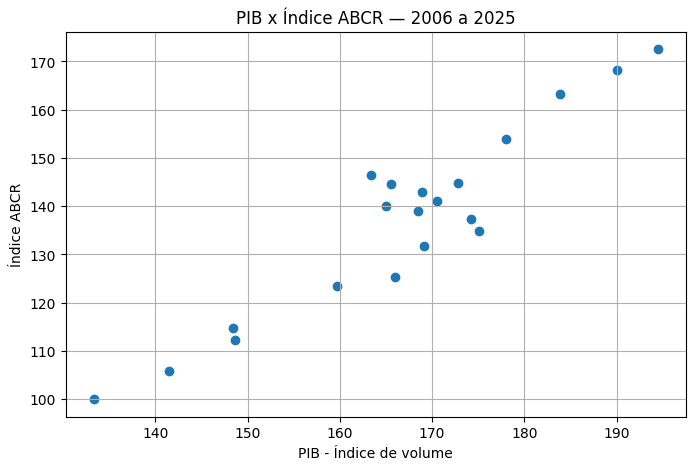

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(dados["PIB_indice"], dados["ABCR_indice"])

plt.xlabel("PIB - Índice de volume")
plt.ylabel("Índice ABCR")
plt.title("PIB x Índice ABCR — 2006 a 2025")
plt.grid()
plt.show()


## 9. Correlação

A correlação de Pearson varia de -1 a 1:

- próxima de **1**: relação linear positiva forte;
- próxima de **0**: pouca relação linear;
- próxima de **-1**: relação linear negativa forte.

A correlação será usada como uma primeira análise antes da regressão.


In [12]:
correlacao = dados["PIB_indice"].corr(dados["ABCR_indice"])

print(f"Correlação entre PIB e ABCR: {correlacao:.4f}")


Correlação entre PIB e ABCR: 0.9424


## 10. Separação entre treino e teste

A atividade pede que os primeiros 16 anos sejam usados para treinamento e os últimos 4 para teste.

Não vamos utilizar `train_test_split`, porque ele pode embaralhar os registros. Como os dados são cronológicos, manter a ordem dos anos é importante.


In [17]:
treino = dados.iloc[:16].copy()
teste = dados.iloc[16:].copy()

X_treino = treino[["PIB_indice"]]
y_treino = treino["ABCR_indice"]

X_teste = teste[["PIB_indice"]]
y_teste = teste["ABCR_indice"]

print("Treino:")
print(treino[["Ano", "PIB_indice", "ABCR_indice"]])

print("\nTeste:")
print(teste[["Ano", "PIB_indice", "ABCR_indice"]])

Treino:
     Ano  PIB_indice  ABCR_indice
0   2006    133.3500       100.00
1   2007    141.4475       105.90
2   2008    148.6525       112.30
3   2009    148.4675       114.80
4   2010    159.6425       123.36
5   2011    165.9850       125.30
6   2012    169.1750       131.65
7   2013    174.2600       137.42
8   2014    175.1400       134.90
9   2015    168.9275       142.86
10  2016    163.3900       146.53
11  2017    165.5550       144.62
12  2018    168.5075       139.03
13  2019    170.5650       141.02
14  2020    164.9775       140.00
15  2021    172.8325       144.75

Teste:
     Ano  PIB_indice  ABCR_indice
16  2022    178.0475     153.8692
17  2023    183.8175     163.2553
18  2024    190.1025     168.3162
19  2025    194.4500     172.5241


## 11. Treinamento da Regressão Linear

A regressão linear procura encontrar uma reta que represente a relação entre o PIB e o Índice ABCR.

A forma simplificada é:

**ABCR = intercepto + coeficiente × PIB**


In [18]:
modelo = LinearRegression()

modelo.fit(X_treino, y_treino)

coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"Coeficiente angular: {coeficiente:.4f}")
print(f"Intercepto: {intercepto:.4f}")
print(f"Equação: ABCR = {intercepto:.4f} + ({coeficiente:.4f} × PIB)")


Coeficiente angular: 1.0708
Intercepto: -43.1139
Equação: ABCR = -43.1139 + (1.0708 × PIB)


## 12. Previsões no conjunto de teste

Agora o modelo treinado recebe os valores de PIB dos quatro anos de teste e estima o Índice ABCR.


In [19]:
y_previsto = modelo.predict(X_teste)

resultado = teste[["Ano", "PIB_indice", "ABCR_indice"]].copy()
resultado["ABCR_previsto"] = y_previsto
resultado["Erro"] = resultado["ABCR_indice"] - resultado["ABCR_previsto"]

display(resultado)


,Ano,PIB_indice,ABCR_indice,ABCR_previsto,Erro
16,2022,178.0475,153.8692,147.536162,6.333038
17,2023,183.8175,163.2553,153.714573,9.540727
18,2024,190.1025,168.3162,160.444438,7.871762
19,2025,194.4500,172.5241,165.099662,7.424438


## 13. Avaliação do modelo

Serão utilizadas três métricas:

### MAE — Erro Absoluto Médio
Mostra, em média, quanto a previsão se afastou do valor real.

### MSE — Erro Quadrático Médio
Calcula os erros ao quadrado. Erros maiores recebem um peso maior.

### R² — Coeficiente de Determinação
Indica quanto da variação do alvo é explicada pelo modelo. Quanto mais próximo de 1, maior a capacidade explicativa dentro daquele conjunto de dados.


In [20]:
mae = mean_absolute_error(y_teste, y_previsto)
mse = mean_squared_error(y_teste, y_previsto)
r2 = r2_score(y_teste, y_previsto)

metricas = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "R²"],
    "Valor": [mae, mse, r2]
})

display(metricas)


,Métrica,Valor
0,MAE,7.792491
1,MSE,62.054939
2,R²,-0.282707


## 14. Comparação entre valores reais e previstos

O gráfico abaixo permite visualizar se as previsões ficaram próximas dos valores observados nos quatro anos de teste.


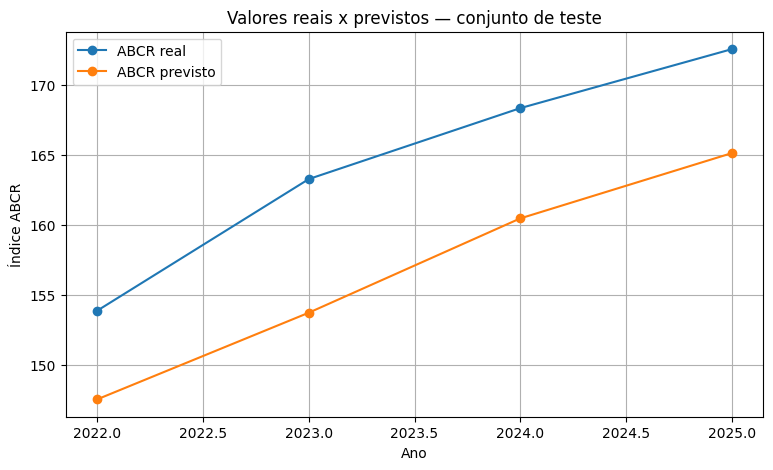

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(resultado["Ano"], resultado["ABCR_indice"], marker="o", label="ABCR real")
plt.plot(resultado["Ano"], resultado["ABCR_previsto"], marker="o", label="ABCR previsto")

plt.xlabel("Ano")
plt.ylabel("Índice ABCR")
plt.title("Valores reais x previstos — conjunto de teste")
plt.legend()
plt.grid()
plt.show()


## 15. Salvando a base final

Além do notebook, o trabalho deve possuir a base de dados utilizada. Esta célula gera um CSV com os 20 anos e as duas variáveis.


In [22]:
dados.to_csv("dados_completos_abcr_pib_2006_2025.csv", index=False, encoding="utf-8-sig")

print("Arquivo 'dados_completos_abcr_pib_2006_2025.csv' criado com sucesso.")


Arquivo 'dados_completos_abcr_pib_2006_2025.csv' criado com sucesso.


## 16. Conclusão

A análise deve ser interpretada a partir de três pontos:

1. **Correlação:** indica se PIB e ABCR apresentam associação linear.
2. **Regressão:** mostra como o ABCR pode ser estimado a partir do PIB dentro dos dados de treinamento.
3. **Métricas:** MAE, MSE e R² mostram o desempenho das previsões nos quatro anos separados para teste.

O resultado não deve ser interpretado como prova de causalidade. Mesmo que a correlação seja alta e o R² seja elevado, outros fatores também podem influenciar o fluxo de veículos, como preço dos combustíveis, renda, produção agrícola, comércio, turismo, infraestrutura e condições econômicas.

### Dificuldades encontradas e soluções

- **Dados em frequências diferentes:** o PIB é trimestral e o ABCR é mensal/anual. A solução foi trabalhar com os números-índice anuais.
- **Ordem cronológica:** o conjunto de teste foi separado pelos últimos quatro anos, sem embaralhamento.
- **Pesquisa das fontes:** foram utilizados o IBGE/SIDRA para o PIB e a ABCR para o fluxo de veículos.
- **Interpretação:** a correlação foi tratada como associação, e não como causalidade.


## Fontes consultadas

- IBGE — Contas Nacionais Trimestrais / SIDRA, Tabela 1620.
- ABCR — Índice ABCR.
- CNT — Pesquisa CNT de Rodovias, série histórica do Índice ABCR.
- Agência iNFRA — divulgação do resultado anual do Índice ABCR de 2025.

**Observação:** o notebook consulta o PIB diretamente pela API do SIDRA quando executado no Google Colab.
